In [15]:
from ovito.io import import_file
from ovito.modifiers import RadialDistributionFunctionModifier

import numpy as np

dump_path = "/media/jrjoseph/Elements/projects/training/water_box_ls6/water_box_nvt_prod_coarse.out"

pipeline = import_file(dump_path)

data = pipeline.compute()

ptype_prop = data.particles_.particle_types_

ptype_prop.type_by_id_(1).name = "O"
ptype_prop.type_by_id_(2).name = "H"

radius_cutoff = 10
bins = 500

n_blocks = 5

In [16]:
pipeline.modifiers.append(
    RadialDistributionFunctionModifier(
        cutoff=radius_cutoff,
        number_of_bins=bins,
        partial=True
    )
)

rdf_frames = []

n_frames = pipeline.source.num_frames

for frame in range(n_frames):

    data = pipeline.compute(frame)

    table = data.tables["coordination-rdf"]

    xy = table.xy()

    rdf_frames.append(xy[:, 1:])  # skip r column

rdf_frames = np.asarray(rdf_frames)

r = xy[:, 0]

print("RDF array shape:", rdf_frames.shape)

if n_frames < n_blocks:
    raise ValueError(
        f"Trajectory has only {n_frames} frames but "
        f"{n_blocks} blocks were requested."
    )

block_size = n_frames // n_blocks

# Discard remainder frames so every block has equal size
usable_frames = block_size * n_blocks

rdf_frames = rdf_frames[:usable_frames]

# Shape:
# (n_blocks, block_size, n_bins, n_pairs)
blocks = rdf_frames.reshape(
    n_blocks,
    block_size,
    rdf_frames.shape[1],
    rdf_frames.shape[2]
)

# Mean RDF within each block
block_means = blocks.mean(axis=1)

# ---------------------------------------------------------
# Statistics
# ---------------------------------------------------------

rdf_mean = block_means.mean(axis=0)

rdf_std = block_means.std(axis=0, ddof=1)

rdf_sem = rdf_std / np.sqrt(n_blocks)

print("rdf_mean shape:", rdf_mean.shape)
print("rdf_std shape:", rdf_std.shape)
print("rdf_sem shape:", rdf_sem.shape)


RDF array shape: (2001, 500, 3)
rdf_mean shape: (500, 3)
rdf_std shape: (500, 3)
rdf_sem shape: (500, 3)


In [17]:
pair_names = ["O-O", "O-H", "H-H"]

rdf_data = {}

for i, pair in enumerate(pair_names):

    rdf_data[pair] = {
        "r": r,
        "mean": rdf_mean[:, i],
        "std": rdf_std[:, i],
        "sem": rdf_sem[:, i]
    }

In [18]:
# ---------------------------------------------------------
# Peak position uncertainties from block averaging
# ---------------------------------------------------------

pair_names = ["O-O", "O-H", "H-H"]

peak_position_data = {}

for i, pair in enumerate(pair_names):

    y = rdf_mean[:, i]

    peaks, _ = find_peaks(
        y,
        prominence=0.05,
        distance=5
    )

    peak_heights = y[peaks]
    strongest = peaks[np.argsort(peak_heights)[::-1][:3]]

    peak_position_data[pair] = {}

    for p in strongest:

        x_peak = r[p]

        block_peak_positions = []

        for block in block_means:

            block_y = block[:, i]

            block_peaks, _ = find_peaks(
                block_y,
                prominence=0.05,
                distance=5
            )

            if len(block_peaks) == 0:
                continue

            nearest_peak = block_peaks[
                np.argmin(np.abs(r[block_peaks] - x_peak))
            ]

            block_peak_positions.append(
                r[nearest_peak]
            )

        peak_position_data[pair][p] = (
            np.std(block_peak_positions, ddof=1)
            if len(block_peak_positions) > 1
            else 0.0
        )

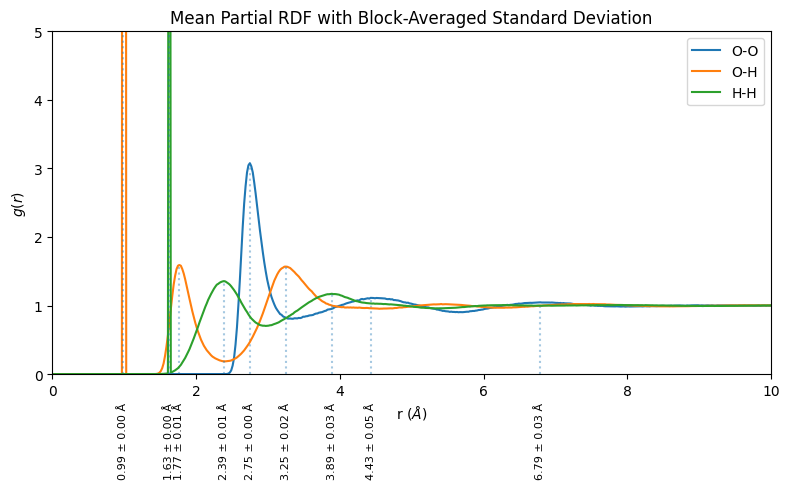

In [19]:
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import numpy as np

pair_names = ["O-O", "O-H", "H-H"]

plt.figure(figsize=(8, 5))

for i, pair in enumerate(pair_names):

    y = rdf_mean[:, i]
    y_std = rdf_std[:, i]

    plt.plot(
        r,
        y,
        label=pair
    )

    plt.fill_between(
        r,
        y - y_std,
        y + y_std,
        alpha=0.5
    )

    peaks, _ = find_peaks(
        y,
        prominence=0.05,
        distance=5
    )

    peak_heights = y[peaks]
    strongest = peaks[np.argsort(peak_heights)[::-1][:3]]

    ax = plt.gca()

    for p in strongest:

        x_peak = r[p]
        y_peak = y[p]

        x_std = peak_position_data[pair][p]

        ax.vlines(
            x_peak,
            ymin=0,
            ymax=y_peak,
            linestyle=":",
            alpha=0.4
        )

        ax.annotate(
            f"{x_peak:.2f} ± {x_std:.2f} Å",
            xy=(x_peak, 0),
            xycoords="data",
            xytext=(0, -20),
            textcoords="offset points",
            ha="center",
            va="top",
            rotation=90,
            fontsize=8,
            annotation_clip=False
        )

plt.xlabel(r"r ($\AA$)")
plt.ylabel(r"$g(r)$")
plt.xlim(0, radius_cutoff)
plt.ylim(0, 5)

plt.title("Mean Partial RDF with Block-Averaged Standard Deviation")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
pair_names = ["O-O", "O-H", "H-H"]

print("\nRDF Peak Summary")
print("-" * 80)

for i, pair in enumerate(pair_names):

    y = rdf_mean[:, i]

    peaks, _ = find_peaks(
        y,
        prominence=0.05,
        distance=5
    )

    peak_heights = y[peaks]
    strongest = peaks[np.argsort(peak_heights)[::-1][:3]]

    print(f"\n{pair}")

    for rank, p in enumerate(strongest, start=1):

        x_peak = r[p]
        x_std = peak_position_data[pair][p]

        y_peak = rdf_mean[p, i]
        y_std = rdf_std[p, i]

        print(
            f"Peak {rank}: "
            f"r = {x_peak:.3f} ± {x_std:.3f} Å, "
            f"g(r) = {y_peak:.3f} ± {y_std:.3f}"
        )


RDF Peak Summary
--------------------------------------------------------------------------------

O-O
Peak 1: r = 2.750 ± 0.000 Å, g(r) = 3.076 ± 0.014
Peak 2: r = 4.430 ± 0.051 Å, g(r) = 1.112 ± 0.006
Peak 3: r = 6.790 ± 0.030 Å, g(r) = 1.047 ± 0.001

O-H
Peak 1: r = 0.990 ± 0.000 Å, g(r) = 60.485 ± 0.122
Peak 2: r = 1.770 ± 0.009 Å, g(r) = 1.591 ± 0.009
Peak 3: r = 3.250 ± 0.017 Å, g(r) = 1.568 ± 0.004

H-H
Peak 1: r = 1.630 ± 0.000 Å, g(r) = 22.479 ± 0.001
Peak 2: r = 2.390 ± 0.014 Å, g(r) = 1.356 ± 0.008
Peak 3: r = 3.890 ± 0.030 Å, g(r) = 1.171 ± 0.003
